# Section 1 Setup & Load Clean Data:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\sadeq\Desktop\Python\Hotel_Booking\data\hotel_bookings_clean.csv')

In [5]:
df['arrival_date'] = pd.to_datetime(df['arrival_date'])

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'],
    categories=month_order,
    ordered=True
)

print(f"arrival_date dtype:       {df['arrival_date'].dtype}")
print(f"arrival_date_month dtype: {df['arrival_date_month'].dtype}")

arrival_date dtype:       datetime64[us]
arrival_date_month dtype: category


====================================================================================================================================================================================================================================

# Section 2 Univariate Analysis:

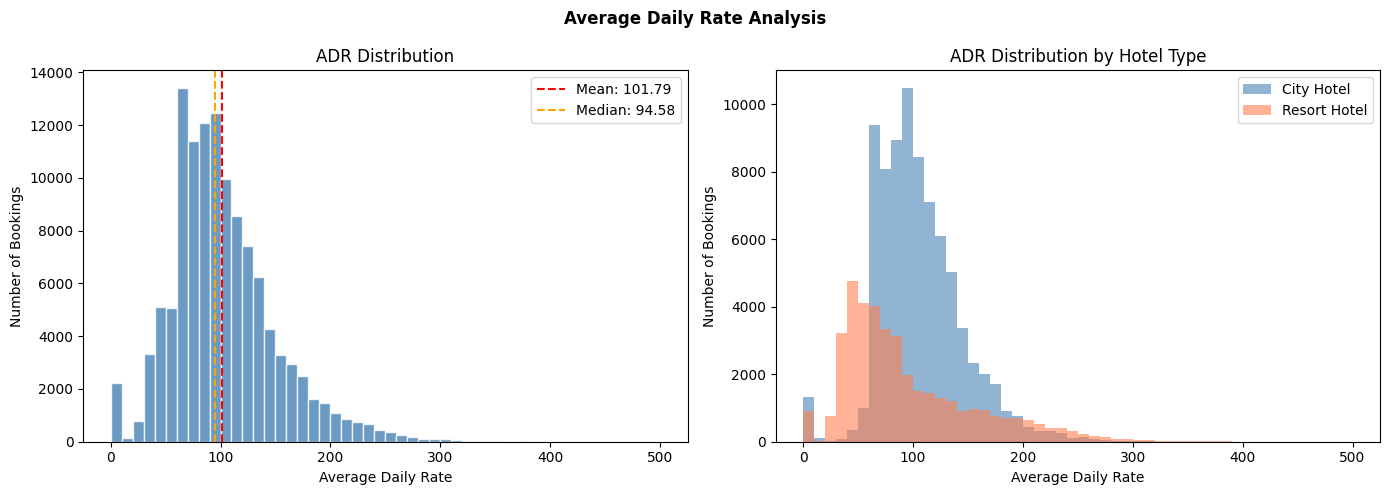

In [6]:
# 2.1 ADR Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['adr'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('ADR Distribution', fontsize=12)
axes[0].set_xlabel('Average Daily Rate')
axes[0].set_ylabel('Number of Bookings')
axes[0].axvline(df['adr'].mean(), color='red', linestyle='--', label=f"Mean: {df['adr'].mean():.2f}")
axes[0].axvline(df['adr'].median(), color='orange', linestyle='--', label=f"Median: {df['adr'].median():.2f}")
axes[0].legend()

axes[1].hist(df[df['hotel']=='City Hotel']['adr'], bins=50, alpha=0.6, color='steelblue', label='City Hotel')
axes[1].hist(df[df['hotel']=='Resort Hotel']['adr'], bins=50, alpha=0.6, color='coral', label='Resort Hotel')
axes[1].set_title('ADR Distribution by Hotel Type', fontsize=12)
axes[1].set_xlabel('Average Daily Rate')
axes[1].set_ylabel('Number of Bookings')
axes[1].legend()

plt.suptitle('Average Daily Rate Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding 2.1:** ADR is right-skewed (mean $101.79, median $94.58), indicating most bookings are budget-to-mid range with a small premium segment pulling the average up. City Hotel shows a tighter, higher-centred distribution while Resort Hotel has greater price variability, reflecting Resort's broader room type mix.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

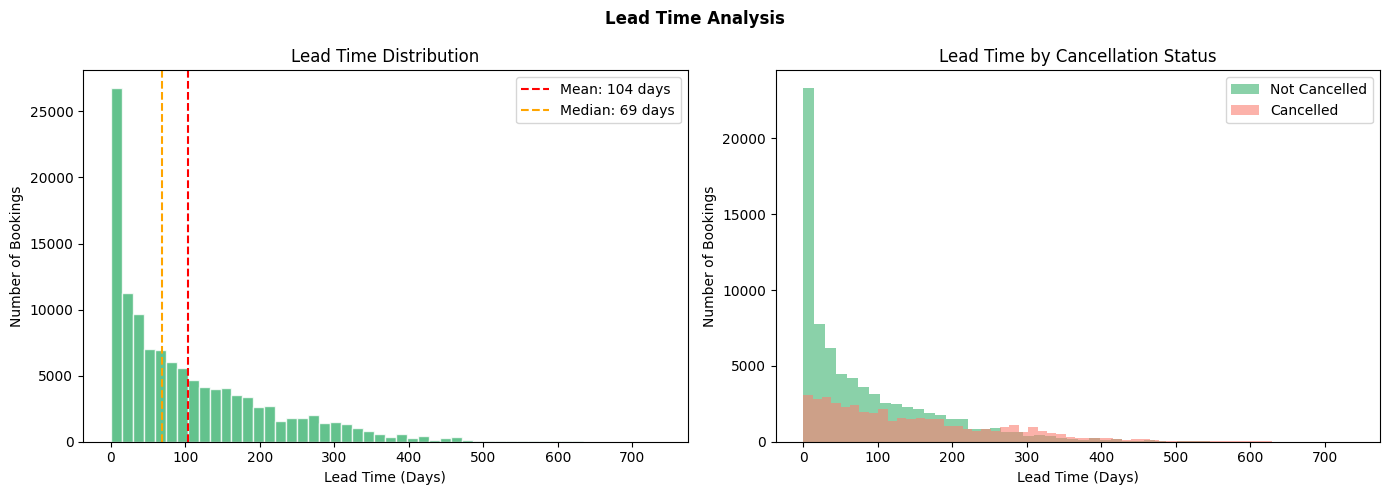

In [7]:
# 2.2 Lead Time Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['lead_time'], bins=50, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[0].set_title('Lead Time Distribution', fontsize=12)
axes[0].set_xlabel('Lead Time (Days)')
axes[0].set_ylabel('Number of Bookings')
axes[0].axvline(df['lead_time'].mean(), color='red', linestyle='--', label=f"Mean: {df['lead_time'].mean():.0f} days")
axes[0].axvline(df['lead_time'].median(), color='orange', linestyle='--', label=f"Median: {df['lead_time'].median():.0f} days")
axes[0].legend()

axes[1].hist(df[df['is_canceled']==0]['lead_time'], bins=50, alpha=0.6, color='mediumseagreen', label='Not Cancelled')
axes[1].hist(df[df['is_canceled']==1]['lead_time'], bins=50, alpha=0.6, color='salmon', label='Cancelled')
axes[1].set_title('Lead Time by Cancellation Status', fontsize=12)
axes[1].set_xlabel('Lead Time (Days)')
axes[1].set_ylabel('Number of Bookings')
axes[1].legend()

plt.suptitle('Lead Time Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding 2.2:** Lead time is heavily right-skewed (median 69 days, mean 104 days), with the majority of bookings made within 30 days of arrival. Critically, cancelled bookings show a visibly longer lead time distribution than non-cancelled bookings guests who book far in advance cancel at much higher rates.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

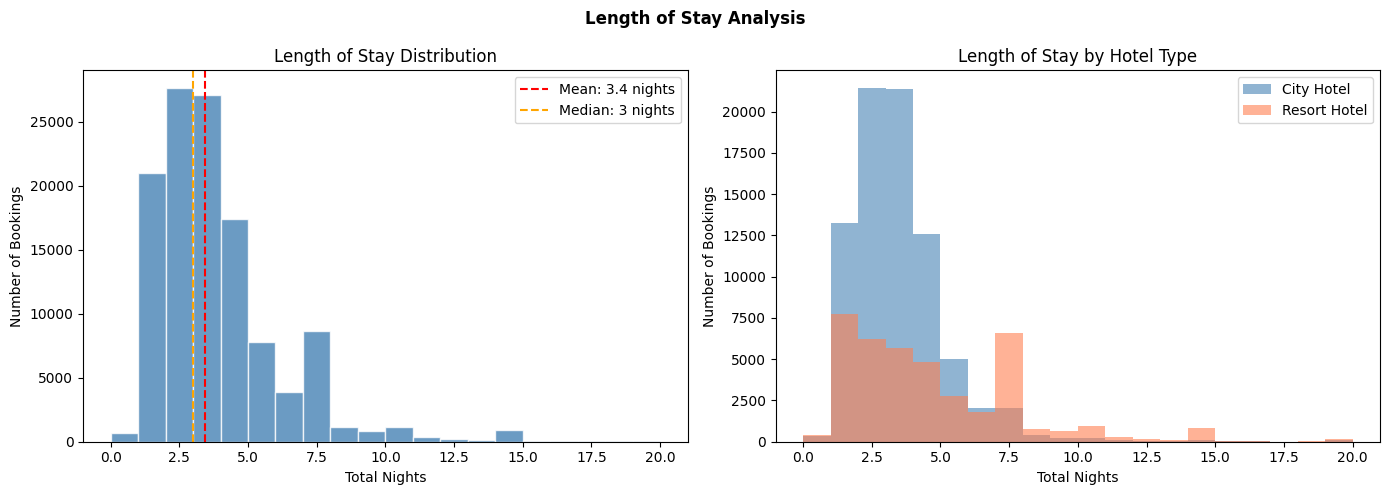

In [8]:
# 2.3 Total Nights Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stay_data = df[df['total_nights'] <= 20]
axes[0].hist(stay_data['total_nights'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Length of Stay Distribution', fontsize=12)
axes[0].set_xlabel('Total Nights')
axes[0].set_ylabel('Number of Bookings')
axes[0].axvline(df['total_nights'].mean(), color='red', linestyle='--', label=f"Mean: {df['total_nights'].mean():.1f} nights")
axes[0].axvline(df['total_nights'].median(), color='orange', linestyle='--', label=f"Median: {df['total_nights'].median():.0f} nights")
axes[0].legend()

city = df[df['hotel']=='City Hotel']['total_nights'].clip(0, 20)
resort = df[df['hotel']=='Resort Hotel']['total_nights'].clip(0, 20)
axes[1].hist(city, bins=20, alpha=0.6, color='steelblue', label='City Hotel')
axes[1].hist(resort, bins=20, alpha=0.6, color='coral', label='Resort Hotel')
axes[1].set_title('Length of Stay by Hotel Type', fontsize=12)
axes[1].set_xlabel('Total Nights')
axes[1].set_ylabel('Number of Bookings')
axes[1].legend()

plt.suptitle('Length of Stay Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding 2.3:** Median stay length is 3 nights overall, but hotel type reveals two distinct guest behaviours. City Hotel guests concentrate at 2–3 nights (business and weekend travellers), while Resort Hotel guests show a secondary peak at 7 nights (full-week holidays) with stays extending to 14+ nights. These patterns imply fundamentally different pricing and operational strategies for each hotel type.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

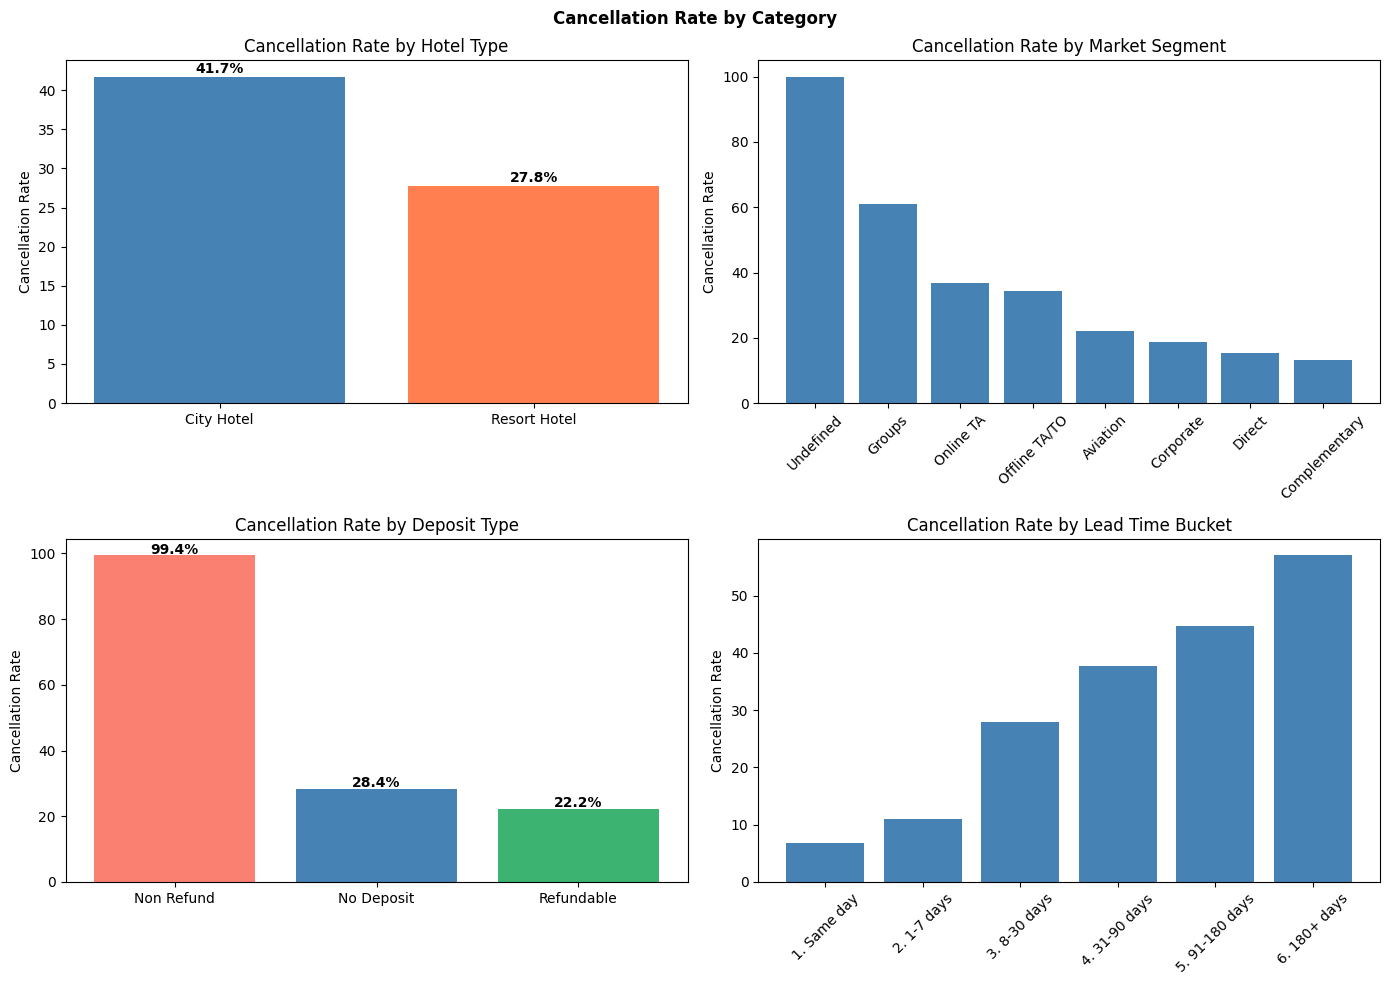

In [9]:
# 2.4 Cancellation Rate by Category

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cancel_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
axes[0,0].bar(cancel_hotel.index, cancel_hotel.values, color=['steelblue', 'coral'])
axes[0,0].set_title('Cancellation Rate by Hotel Type', fontsize=12)
axes[0,0].set_ylabel('Cancellation Rate')
for i, v in enumerate(cancel_hotel.values):
    axes[0,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

cancel_segment = df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False) * 100
axes[0,1].bar(cancel_segment.index, cancel_segment.values, color='steelblue')
axes[0,1].set_title('Cancellation Rate by Market Segment', fontsize=12)
axes[0,1].set_ylabel('Cancellation Rate')
axes[0,1].tick_params(axis='x', rotation=45)

cancel_deposit = df.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False) * 100
axes[1,0].bar(cancel_deposit.index, cancel_deposit.values, color=['salmon', 'steelblue', 'mediumseagreen'])
axes[1,0].set_title('Cancellation Rate by Deposit Type', fontsize=12)
axes[1,0].set_ylabel('Cancellation Rate')
for i, v in enumerate(cancel_deposit.values):
    axes[1,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

cancel_lead = df.groupby('lead_time_bucket')['is_canceled'].mean().sort_index() * 100
axes[1,1].bar(cancel_lead.index, cancel_lead.values, color='steelblue')
axes[1,1].set_title('Cancellation Rate by Lead Time Bucket', fontsize=12)
axes[1,1].set_ylabel('Cancellation Rate')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Cancellation Rate by Category', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding 2.4:**
1. City Hotel cancels at 41.7% vs Resort Hotel 27.8% , a significant operational gap
2. Groups (61%) and Online TA (38%) are the highest-risk segments by cancellation rate
3. Non-Refund deposits show 99.4% cancellation — but represent guaranteed revenue, not revenue loss (deposit is non-refundable)
4. Cancellation rate increases monotonically with lead time, from 7% (same day) to 58% (180+ days), a near-perfect linear risk relationship

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

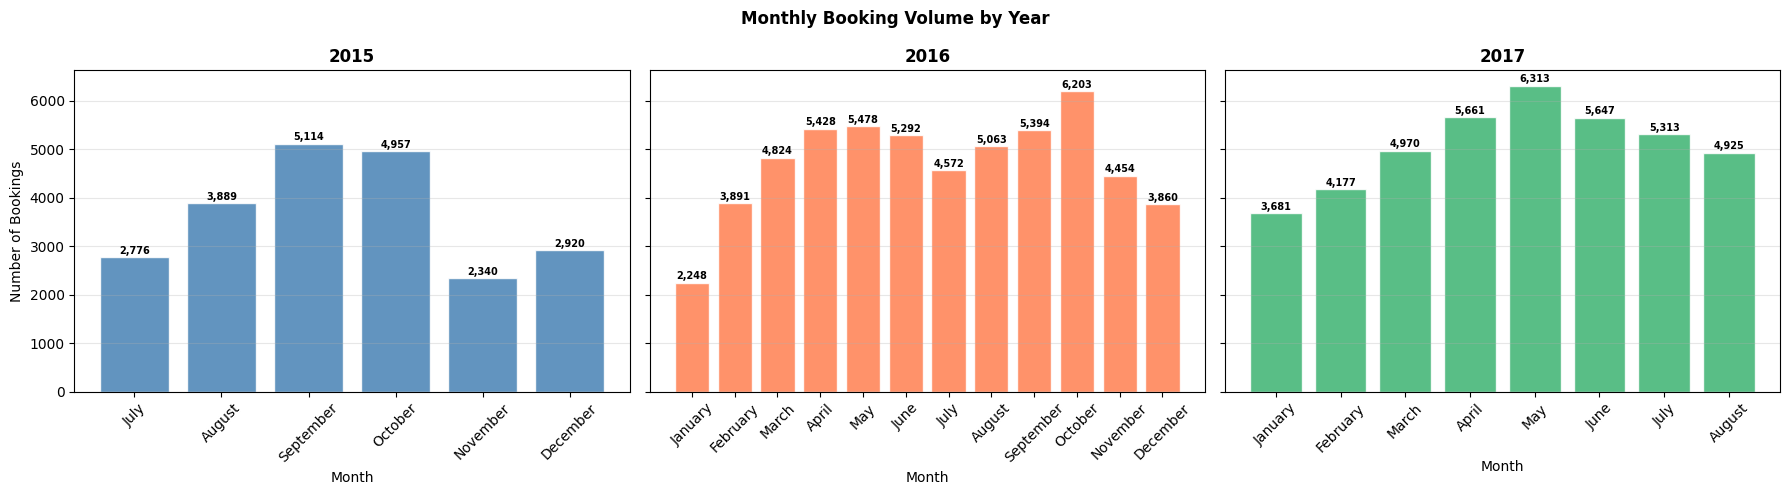

In [12]:
# 2.5 Booking Volume by Month 

monthly = (df.groupby(['arrival_date_year', 'arrival_date_month'])['booking_id']
             .count()
             .reset_index())
monthly.columns = ['year', 'month', 'bookings']

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

colors = {2015: 'steelblue', 2016: 'coral', 2017: 'mediumseagreen'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, year in enumerate([2015, 2016, 2017]):
    year_data = monthly[monthly['year'] == year].copy()
    year_data['month'] = pd.Categorical(year_data['month'], categories=month_order, ordered=True)
    year_data = year_data.sort_values('month')

    axes[i].bar(year_data['month'].astype(str), year_data['bookings'],
                color=colors[year], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{year}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Month')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 30,
                     f'{int(bar.get_height()):,}',
                     ha='center', va='bottom', fontsize=7, fontweight='bold')

axes[0].set_ylabel('Number of Bookings')

plt.suptitle('Monthly Booking Volume by Year', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



**Finding 2.5:** Booking volume follows a clear seasonal pattern with October being the peak month (6,203 in 2016), reflecting Portugal's popular shoulder season. January is consistently the slowest month. Year-over-year comparison shows healthy growth across most months in 2017 vs 2016, with January showing exceptional +64% growth suggesting successful off-season demand generation

====================================================================================================================================================================================================================================

# Section 3 Bivariate Analysis:

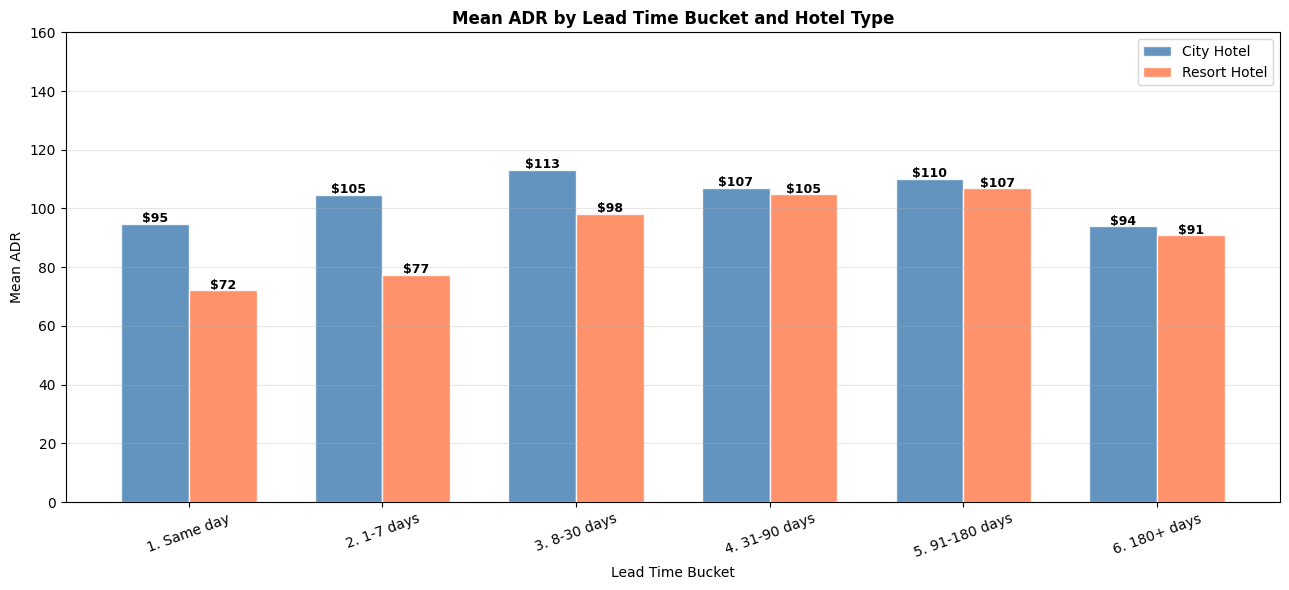

In [ ]:
# 3.1 Lead Time vs ADR

bucket_order = ['1. Same day', '2. 1-7 days', '3. 8-30 days',
                '4. 31-90 days', '5. 91-180 days', '6. 180+ days']

adr_lead = (df.groupby(['lead_time_bucket', 'hotel'])['adr']
              .mean()
              .unstack()
              .reindex(bucket_order))

x = np.arange(len(bucket_order))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width/2, adr_lead['City Hotel'], width,
               label='City Hotel', color='steelblue', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, adr_lead['Resort Hotel'], width,
               label='Resort Hotel', color='coral', edgecolor='white', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'${bar.get_height():.0f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'${bar.get_height():.0f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Mean ADR by Lead Time Bucket and Hotel Type', fontsize=12, fontweight='bold')
ax.set_xlabel('Lead Time Bucket')
ax.set_ylabel('Mean ADR')
ax.set_xticks(x)
ax.set_xticklabels(bucket_order, rotation=20)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 160)
plt.tight_layout()
plt.show()


**Finding 3.1:** ADR follows an inverted U-shape across lead time buckets for both hotel types. Peak rates occur at 8-30 days (City: $113, Resort: $98) the optimal booking window where hotels charge full price. Same-day bookings are discounted (City: $95, Resort: $72) reflecting last-minute inventory clearance, while 180+ day bookings are also lower (City: $94, Resort: $91) suggesting early-bird promotional pricing. City Hotel commands a consistent $18-23 premium over Resort Hotel across all lead time buckets.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

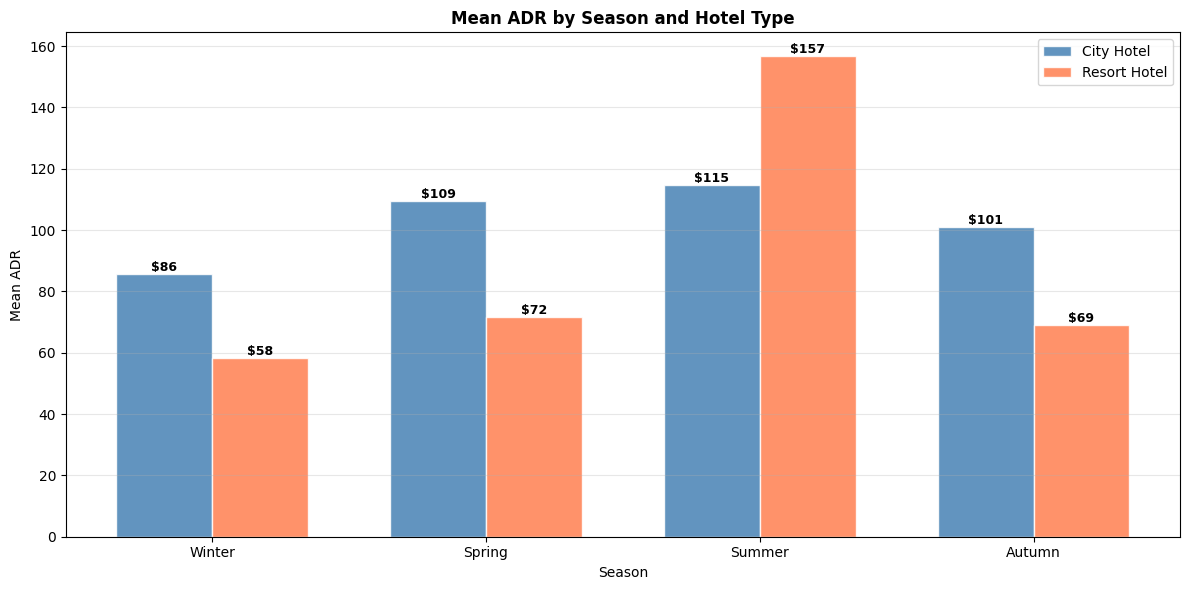

In [65]:
# 3.2 ADR by Season × Hotel Type

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
hotel_types = ['City Hotel', 'Resort Hotel']
colors = {'City Hotel': 'steelblue', 'Resort Hotel': 'coral'}

x = np.arange(len(season_order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

for i, hotel in enumerate(hotel_types):
    means = [df[(df['season'] == s) & (df['hotel'] == hotel)]['adr'].mean()
             for s in season_order]
    bars = ax.bar(x + i * width, means, width, label=hotel,
                  color=colors[hotel], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'${val:.0f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Mean ADR by Season and Hotel Type', fontsize=12, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Mean ADR')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(season_order)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Finding 3.2:** Resort Hotel demonstrates extreme seasonal pricing power, ADR swings from $58 (Winter) to $157 (Summer), a 170% increase. City Hotel remains relatively stable ($86 Winter to $115 Summer, +34%). Critically, 
Resort Hotel overtakes City Hotel only in Summer ($157 vs $115), reflecting Portugal's beach tourism peak. This suggests Resort Hotels should focus revenue strategy on maximising Summer yield while developing off-season 
demand generation programmes to offset Winter's $58 ADR

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

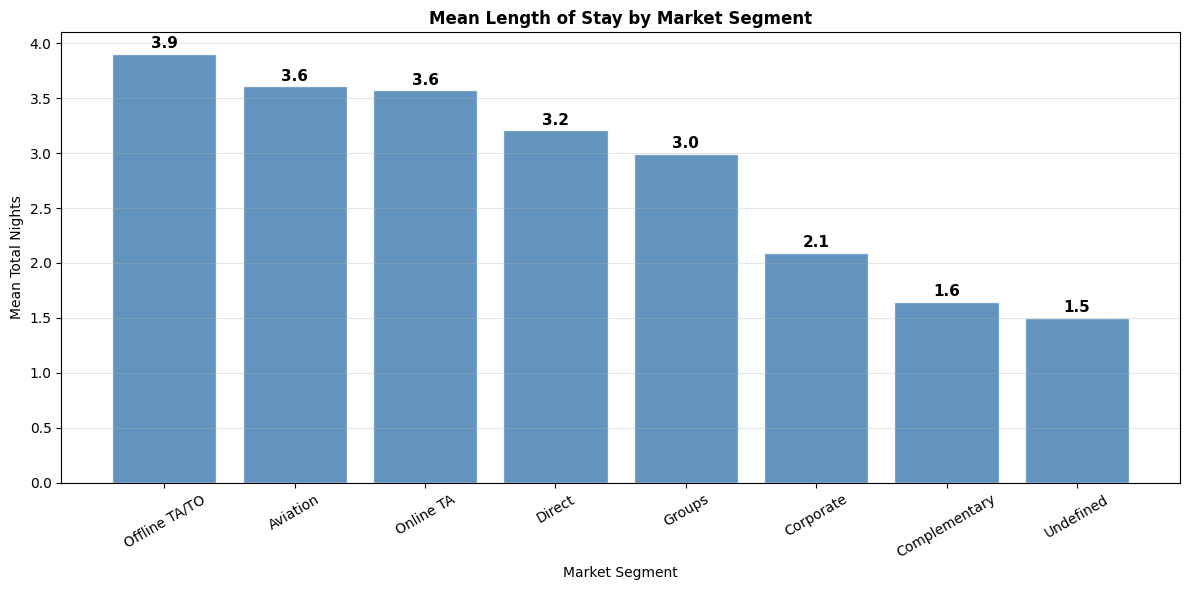

In [70]:
# 3.3 Mean Length of Stay by Market Segment

segment_means = (df.groupby('market_segment')['total_nights']
                   .mean()
                   .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(segment_means.index, segment_means.values,
              color='steelblue', edgecolor='white', alpha=0.85)

for bar, val in zip(bars, segment_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)

ax.set_title('Mean Length of Stay by Market Segment', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Total Nights')
ax.set_xlabel('Market Segment')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Finding 3.3: Offline TA/TO (3.9 nights) and Aviation (3.6 nights) stay longest leisure guests on proper holidays. Corporate (2.1 nights) and Complementary (1.6 nights) stay shortest in for meetings, out quickly. 
The 2.4-night gap reflects fundamentally different trip purposes across segments.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

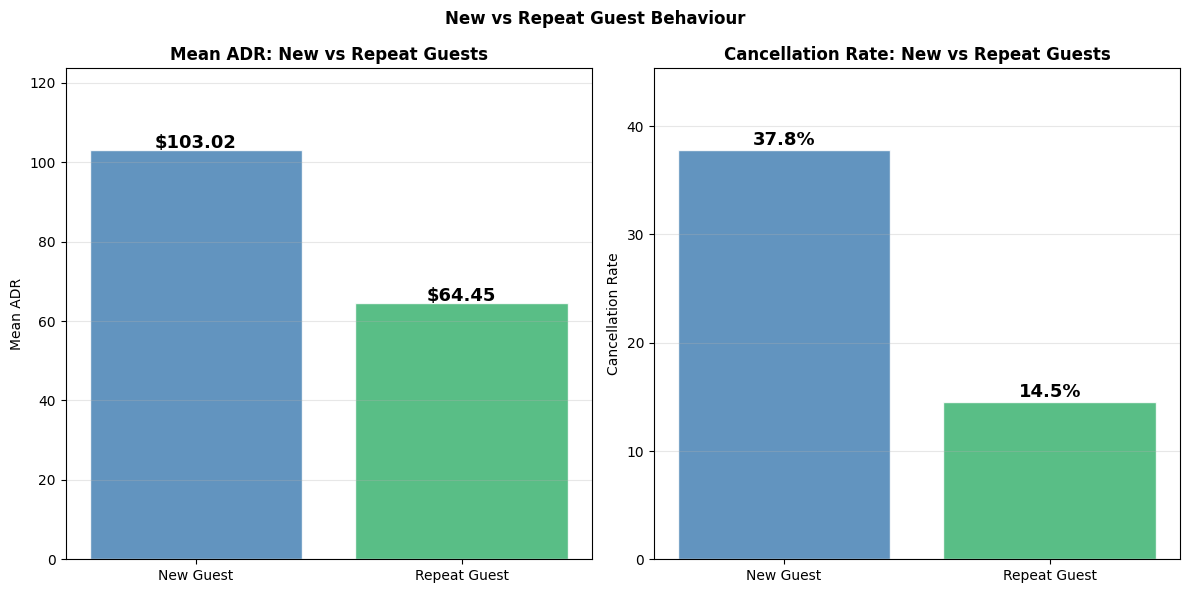

In [76]:
# 3.4 Repeat vs New Guest Behaviour

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

labels = ['New Guest', 'Repeat Guest']
colors = ['steelblue', 'mediumseagreen']

adr_vals = [df[df['is_repeated_guest'] == 0]['adr'].mean(),
            df[df['is_repeated_guest'] == 1]['adr'].mean()]
bars = axes[0].bar(labels, adr_vals, color=colors, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, adr_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${val:.2f}', ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Mean ADR: New vs Repeat Guests', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean ADR')
axes[0].set_ylim(0, max(adr_vals) * 1.2)
axes[0].grid(axis='y', alpha=0.3)


cancel_vals = [df[df['is_repeated_guest'] == 0]['is_canceled'].mean() * 100,
               df[df['is_repeated_guest'] == 1]['is_canceled'].mean() * 100]
bars = axes[1].bar(labels, cancel_vals, color=colors, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, cancel_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('Cancellation Rate: New vs Repeat Guests', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cancellation Rate')
axes[1].set_ylim(0, max(cancel_vals) * 1.2)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('New vs Repeat Guest Behaviour', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



**Finding 3.4:** Repeat guests (3.2% of bookings) pay significantly less ($64.45 vs $103.02 ADR, -37%) but cancel at less than half the rate of new guests (14.5% vs 37.8%). The reduced cancellation risk makes repeat guests 
disproportionately valuable despite lower ADR, a $64 confirmed booking outperforms a $103 booking with 38% cancellation probability. This strongly supports investment in loyalty programmes and repeat guest incentives.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

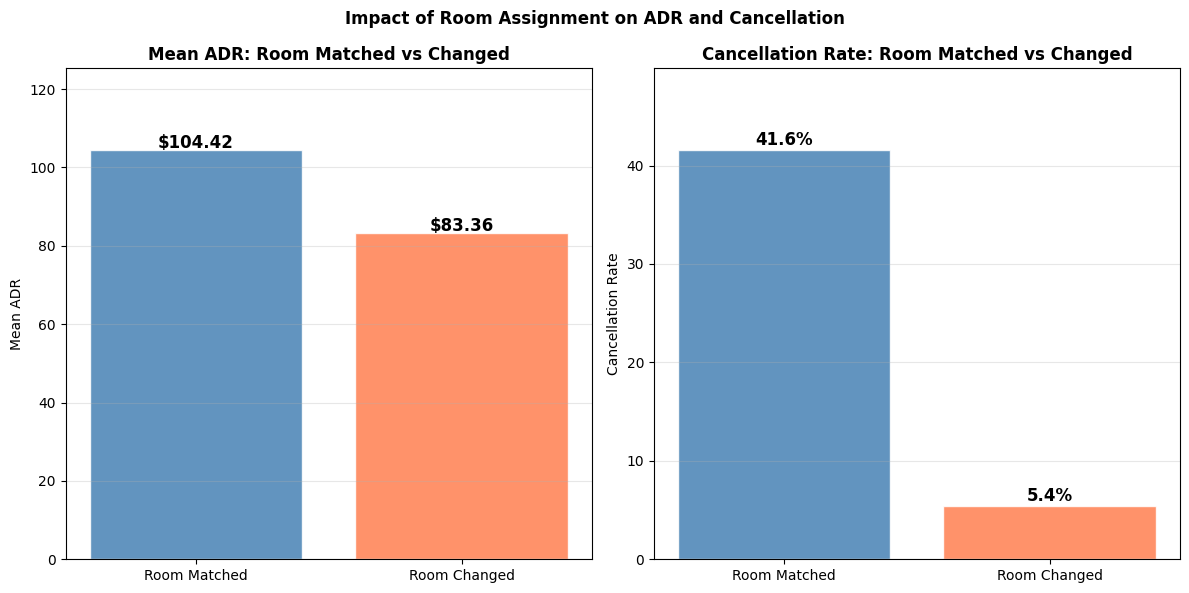

In [81]:
# 3.5 Room Match vs Room Change Impact

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

labels = ['Room Matched', 'Room Changed']
colors = ['steelblue', 'coral']

# Left: Mean ADR
adr_vals = [df[df['room_match'] == 1]['adr'].mean(),
            df[df['room_match'] == 0]['adr'].mean()]
bars = axes[0].bar(labels, adr_vals, color=colors, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, adr_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${val:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Mean ADR: Room Matched vs Changed', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean ADR')
axes[0].set_ylim(0, max(adr_vals) * 1.2)
axes[0].grid(axis='y', alpha=0.3)

# Right: Cancellation rate
cancel_vals = [df[df['room_match'] == 1]['is_canceled'].mean() * 100,
               df[df['room_match'] == 0]['is_canceled'].mean() * 100]
bars = axes[1].bar(labels, cancel_vals, color=colors, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, cancel_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Cancellation Rate: Room Matched vs Changed', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cancellation Rate')
axes[1].set_ylim(0, max(cancel_vals) * 1.2)
axes[1].grid(axis='y', alpha=0.3)


plt.suptitle('Impact of Room Assignment on ADR and Cancellation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



**Finding 3.5:** Room-changed guests (upgrades) pay less on average ($83.36 vs $104.42 ADR) but cancel at a dramatically lower rate (5.4% vs 41.6%). This confirms that room changes are predominantly upgrades guests receiving better rooms than booked are highly satisfied and virtually never cancel. Hotels should consider strategic upgrades as a low-cost retention tool, particularly for high-risk bookings with long lead times or no deposit.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

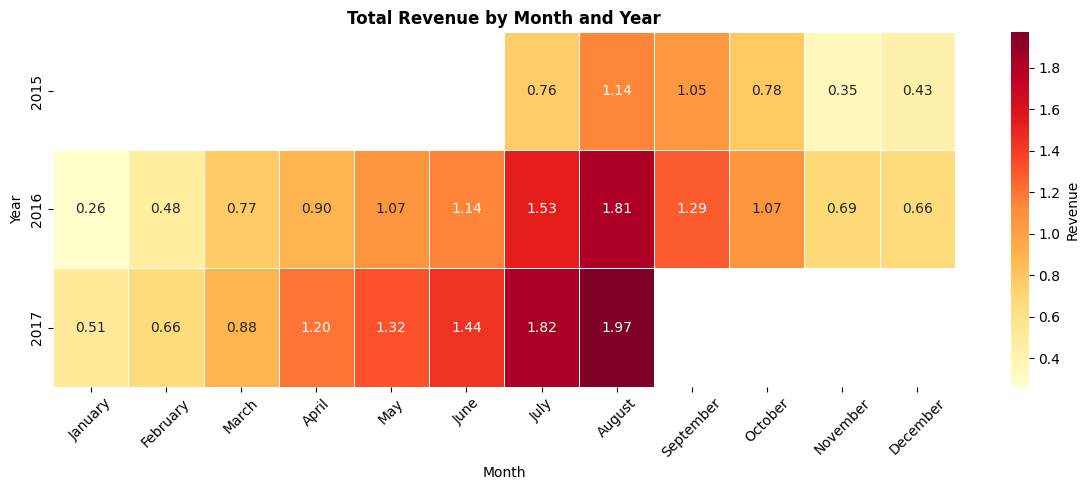

In [86]:
# 3.6 Revenue Heatmap by Month and Year

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

revenue_pivot = (df[df['is_canceled'] == 0]
                 .groupby(['arrival_date_year', 'arrival_date_month'])['total_revenue']
                 .sum()
                 .unstack()
                 .reindex(columns=month_order))
revenue_pivot.index = ['2015', '2016', '2017']
revenue_pivot_m = revenue_pivot / 1_000_000

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(revenue_pivot_m,
            annot=True, fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Revenue'},
            mask=revenue_pivot_m.isna())

ax.set_title('Total Revenue by Month and Year',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Finding 3.6:** Revenue shows extreme seasonality, August 2017 peaked at $1.97M while January 2016 reached only $0.26M, a 7.6× difference between best and worst months. Year-over-year growth is strong across all available 
months in 2017 vs 2016, with January nearly doubling (+96%), suggesting successful off-season demand generation. Summer months (July-August) consistently generate 3-4× the revenue of winter months, creating significant cash flow seasonality that requires careful financial planning.

====================================================================================================================================================================================================================================

# Section 4 Correlation Analysis:

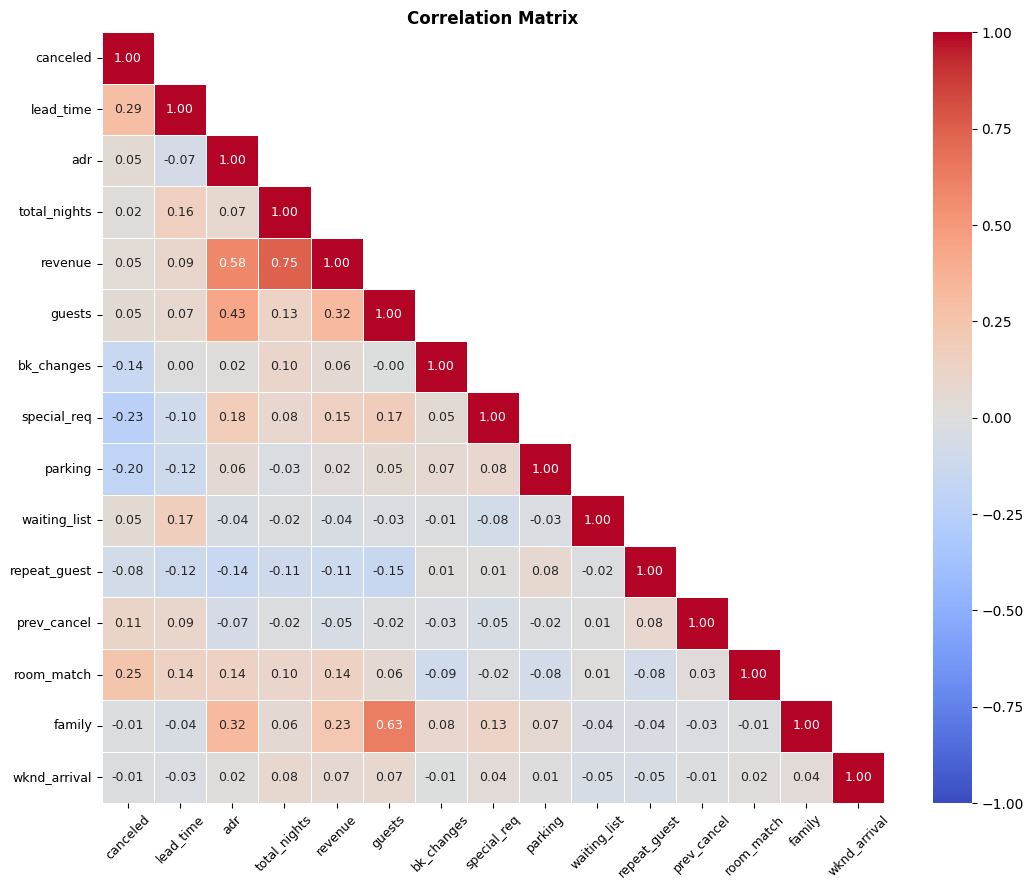

In [92]:
numeric_cols = [
    'is_canceled', 'lead_time', 'adr', 'total_nights', 'total_revenue',
    'total_guests', 'booking_changes', 'total_of_special_requests',
    'required_car_parking_spaces', 'days_in_waiting_list',
    'is_repeated_guest', 'previous_cancellations',
    'room_match', 'is_family', 'is_weekend_arrival'
]

short_labels = [
    'canceled', 'lead_time', 'adr', 'total_nights', 'revenue',
    'guests', 'bk_changes', 'special_req',
    'parking', 'waiting_list',
    'repeat_guest', 'prev_cancel',
    'room_match', 'family', 'wknd_arrival'
]

corr_matrix = df[numeric_cols].corr()
corr_matrix.columns = short_labels
corr_matrix.index = short_labels

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})

ax.set_title('Correlation Matrix', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()


**Finding 4:** Key correlations with cancellation risk: lead_time (+0.29) is the strongest predictor — guests booking far in advance cancel more. Special requests (-0.23) and parking requirements (-0.20) are negative predictors guests with concrete plans cancel less. Notably, ADR shows near-zero correlation with cancellation (0.05), meaning price point is not a useful cancellation risk signal. Revenue is driven primarily by total_nights (0.75) and adr (0.58). These correlations directly inform Week 5 feature selection for the ML cancellation prediction model.

====================================================================================================================================================================================================================================

# Section 5 Statistical Validation:

In [98]:
# 5.1 T-test: Does hotel type significantly affect ADR?

city_adr = df[df['hotel'] == 'City Hotel']['adr']
resort_adr = df[df['hotel'] == 'Resort Hotel']['adr']

t_stat, p_val = stats.ttest_ind(city_adr, resort_adr)

print(f"City Hotel   — Mean ADR: ${city_adr.mean():.2f} (n={len(city_adr):,})")
print(f"Resort Hotel — Mean ADR: ${resort_adr.mean():.2f} (n={len(resort_adr):,})")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val:.6f}")
print()



City Hotel   — Mean ADR: $105.24 (n=79,330)
Resort Hotel — Mean ADR: $94.95 (n=40,060)
T-statistic: 35.0326
P-value:     0.000000



Test 5.1 Result: SIGNIFICANT (t=35.03, p<0.001)  
City Hotel charges significantly more than Resort Hotel on average ($105.24 vs $94.95, +$10.29). With p≈0, this difference is statistically certain. .

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [102]:
# 5.2 Chi-square: Does deposit type affect cancellation?

contingency = pd.crosstab(df['deposit_type'], df['is_canceled'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

print("Observed counts:")
print(contingency)
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"P-value:              {p_val:.6f}")
print()


Observed counts:
is_canceled       0      1
deposit_type              
No Deposit    74947  29694
Non Refund       93  14494
Refundable      126     36

Chi-square statistic: 27677.3292
Degrees of freedom:   2
P-value:              0.000000



**Test 5.2 Result: SIGNIFICANT (χ²=27,677, df=2, p<0.001)  
Deposit type and cancellation status are strongly dependent, not independent.Non-Refund deposits show 99.4% recorded cancellation rate but represent guaranteed revenue (hotel retains deposit). Refundable deposits show the 
lowest real cancellation rate (22.2%), while No Deposit bookings cancel at 28.4%. Deposit policy is the single most powerful lever for managing cancellation risk and revenue certainty.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [104]:
# 5.3 T-test: Does lead time differ between cancelled and not?

lead_cancelled = df[df['is_canceled'] == 1]['lead_time']
lead_not_cancelled = df[df['is_canceled'] == 0]['lead_time']

t_stat, p_val = stats.ttest_ind(lead_cancelled, lead_not_cancelled)

print(f"Cancelled: Mean lead time: {lead_cancelled.mean():.1f} days (n={len(lead_cancelled):,})")
print(f"Not Cancelled: Mean lead time: {lead_not_cancelled.mean():.1f} days (n={len(lead_not_cancelled):,})")
print(f"Difference:     {lead_cancelled.mean() - lead_not_cancelled.mean():.1f} days")
print(f"T-statistic:  {t_stat:.4f}")
print(f"P-value:      {p_val:.6f}")
print()

Cancelled: Mean lead time: 144.8 days (n=44,224)
Not Cancelled: Mean lead time: 80.0 days (n=75,166)
Difference:     64.9 days
T-statistic:  105.9349
P-value:      0.000000



Test 5.3 Result: SIGNIFICANT (t=105.93, p<0.001)  
Cancelled bookings have a mean lead time of 144.8 days vs 80.0 days for completed bookings, a 64.9 day difference that is statistically certain. Lead time is the strongest single predictor of cancellation 
risk in this dataset. Hotels can use lead time thresholds as an immediate operational tool to flag high-risk bookings for targeted retention interventions such as reminder emails, upgrade offers, or deposit requirement adjustments.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [107]:
# 5.4 ANOVA: Does market segment significantly affect ADR?

segments = df['market_segment'].unique()
segment_groups = [df[df['market_segment'] == s]['adr'].values for s in segments]

f_stat, p_val = stats.f_oneway(*segment_groups)

print("Mean ADR by segment:")
for s in sorted(segments):
    mean = df[df['market_segment'] == s]['adr'].mean()
    n = len(df[df['market_segment'] == s])
    print(f"  {s:20s} — ${mean:.2f} (n={n:,})")
print(f"\nF-statistic: {f_stat:.4f}")
print(f"P-value:     {p_val:.6f}")
print()

Mean ADR by segment:
  Aviation             — $100.14 (n=237)
  Complementary        — $2.89 (n=743)
  Corporate            — $69.36 (n=5,295)
  Direct               — $115.45 (n=12,606)
  Groups               — $79.48 (n=19,811)
  Offline TA/TO        — $87.15 (n=24,219)
  Online TA            — $117.20 (n=56,477)
  Undefined            — $15.00 (n=2)

F-statistic: 3191.4425
P-value:     0.000000



Test 5.4 Result: SIGNIFICANT** (F=3,191.44, p<0.001)  
ADR differs significantly across market segments, ranging from $2.89 (Complementary) to $117.20 (Online TA). Online TA generates the highest ADR and represents 47% of all bookings but carries 38% cancellation risk. 
Direct bookings achieve nearly identical ADR ($115.45) with lower cancellation risk and no OTA commission, making direct booking conversion a high-priority revenue strategy. Corporate segment's low ADR ($69.36) is offset by booking volume reliability.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [109]:
# 5.5 Tukey HSD: Which specific segments differ in ADR?

tukey = pairwise_tukeyhsd(df['adr'], df['market_segment'], alpha=0.05)

results_df = pd.DataFrame(data=tukey._results_table.data[1:],
                           columns=tukey._results_table.data[0])
results_df['p-adj'] = pd.to_numeric(results_df['p-adj'])
significant = results_df[results_df['reject'] == True]
print(f"Significant pairs: {len(significant)} out of {len(results_df)} total")
print()
print(significant[['group1', 'group2', 'meandiff', 'p-adj']].to_string(index=False))
print()

Significant pairs: 23 out of 28 total

       group1        group2  meandiff  p-adj
     Aviation Complementary  -97.2557 0.0000
     Aviation     Corporate  -30.7847 0.0000
     Aviation        Direct   15.3031 0.0000
     Aviation        Groups  -20.6623 0.0000
     Aviation Offline TA/TO  -12.9901 0.0002
     Aviation     Online TA   17.0550 0.0000
Complementary     Corporate   66.4711 0.0000
Complementary        Direct  112.5588 0.0000
Complementary        Groups   76.5934 0.0000
Complementary Offline TA/TO   84.2657 0.0000
Complementary     Online TA  114.3107 0.0000
    Corporate        Direct   46.0877 0.0000
    Corporate        Groups   10.1224 0.0000
    Corporate Offline TA/TO   17.7946 0.0000
    Corporate     Online TA   47.8396 0.0000
       Direct        Groups  -35.9654 0.0000
       Direct Offline TA/TO  -28.2931 0.0000
       Direct     Online TA    1.7519 0.0015
       Direct     Undefined -100.4452 0.0287
       Groups Offline TA/TO    7.6723 0.0000
       Groups   

Test 5.5 Result-Tukey HSD Post-hoc:
23 of 28 segment pairs show significantly different ADR. Three pricing 
tiers emerge:
- Premium ($115-117): Online TA and Direct, statistically identical ADR (Δ$1.75, p=0.0015) meaning hotels can match OTA prices for direct bookings while eliminating 15-20% OTA commission
- Mid-tier ($79-100): Aviation, Offline TA/TO, Groups
- Discount ($2-69): Corporate (relationship pricing), Complementary (free)

Key insight: Direct and Online TA are statistically near-identical in ADR, direct booking conversion costs nothing in rate competitiveness but saves significant commission costs.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [117]:
# 5.6 ANOVA: Does season significantly affect ADR?

season_groups = [df[df['season'] == s]['adr'].values 
                 for s in ['Winter', 'Spring', 'Summer', 'Autumn']]

f_stat, p_val = stats.f_oneway(*season_groups)


for s, g in zip(['Winter', 'Spring', 'Summer', 'Autumn'], season_groups):
    print(f"  {s:8s}- Mean ADR: ${g.mean():.2f} (n={len(g):,})")
print(f"\nF-statistic: {f_stat:.4f}")
print(f"P-value:     {p_val:.6f}")

  Winter  - Mean ADR: $75.11 (n=20,777)
  Spring  - Mean ADR: $97.33 (n=32,674)
  Summer  - Mean ADR: $128.77 (n=37,477)
  Autumn  - Mean ADR: $90.87 (n=28,462)

F-statistic: 7949.1537
P-value:     0.000000


Test 5.6 Result: SIGNIFICANT (F=7,949.15, p<0.001)  
Season is the single strongest driver of ADR variation in the dataset (highest F-statistic of all tests). 
ADR ranges from $75.11 (Winter) to $128.77 (Summer), a 71% seasonal premium that is statistically certain. 
Spring ($97.33) and Autumn ($90.87) are comparable shoulder seasons. 
Dynamic seasonal pricing is not just practised, it is statistically justified by demand patterns. Resort Hotels show even more extreme seasonality (170% Winter-to-Summer swing) than City Hotels (34%).

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [119]:
# 5.7 T-test: Do repeat guests pay significantly different ADR?

new_adr = df[df['is_repeated_guest'] == 0]['adr']
repeat_adr = df[df['is_repeated_guest'] == 1]['adr']

t_stat, p_val = stats.ttest_ind(new_adr, repeat_adr)


print(f"New guests - Mean ADR: ${new_adr.mean():.2f} (n={len(new_adr):,})")
print(f"Repeat guests - Mean ADR: ${repeat_adr.mean():.2f} (n={len(repeat_adr):,})")
print(f"Difference:     ${new_adr.mean() - repeat_adr.mean():.2f}")
print(f"T-statistic:  {t_stat:.4f}")
print(f"P-value:      {p_val:.6f}")
print()

New guests - Mean ADR: $103.02 (n=115,580)
Repeat guests - Mean ADR: $64.45 (n=3,810)
Difference:     $38.58
T-statistic:  49.1289
P-value:      0.000000



Test 5.7 Result: SIGNIFICANT (t=49.13, p<0.001)  
Repeat guests pay significantly less than new guests ($64.45 vs $103.02, $38.58 or -37%). Despite the large ADR discount, repeat guests cancel 
at less than half the rate (14.5% vs 37.8%), eliminating OTA acquisition costs and providing reliable revenue. When adjusted for cancellation probability and acquisition cost, the effective revenue difference between new and repeat guests narrows substantially, making loyalty pricing a financially rational strategy.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [121]:
# 5.8 Chi-square: Does room match affect cancellation?

contingency = pd.crosstab(df['room_match'], df['is_canceled'])
contingency.index = ['Room Changed', 'Room Matched']

chi2, p_val, dof, expected = stats.chi2_contingency(contingency)


print("Observed counts:")
print(contingency)
cancel_changed = df[df['room_match']==0]['is_canceled'].mean()*100
cancel_matched = df[df['room_match']==1]['is_canceled'].mean()*100
print(f"\nCancellation rate — Room Changed: {cancel_changed:.1f}%")
print(f"Cancellation rate — Room Matched: {cancel_matched:.1f}%")
print(f"\nChi-square: {chi2:.4f}")
print(f"P-value:    {p_val:.6f}")
print()

Observed counts:
is_canceled       0      1
Room Changed  14115    802
Room Matched  61051  43422

Cancellation rate — Room Changed: 5.4%
Cancellation rate — Room Matched: 41.6%

Chi-square: 7327.8180
P-value:    0.000000



Test 5.8 Result: SIGNIFICANT** (χ²=7,327.82, p<0.001)  
Room assignment and cancellation are strongly dependent. Room-changed guests (upgrades) cancel at only 5.4% vs 41.6% for room-matched guests, a 36.2 percentage point gap that is statistically certain. Causality likely runs from guest commitment to upgrade (not the reverse),committed guests receive upgrades AND don't cancel. Room-changed bookings represent the hotel's most reliable revenue segment with 94.6% show-up rate, enabling highly accurate revenue forecasting for this group.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
# 5.9 T-test: Does weekend arrival affect ADR?

weekday_adr = df[df['is_weekend_arrival'] == 0]['adr']
weekend_adr = df[df['is_weekend_arrival'] == 1]['adr']

t_stat, p_val = stats.ttest_ind(weekday_adr, weekend_adr)

print(f"Weekday arrivals — Mean ADR: ${weekday_adr.mean():.2f} (n={len(weekday_adr):,})")
print(f"Weekend arrivals — Mean ADR: ${weekend_adr.mean():.2f} (n={len(weekend_adr):,})")
print(f"Difference:        ${abs(weekday_adr.mean() - weekend_adr.mean()):.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val:.6f}")
print()

Weekday arrivals — Mean ADR: $101.31 (n=87,194)
Weekend arrivals — Mean ADR: $103.10 (n=32,196)
Difference:        $1.79
T-statistic: -5.7035
P-value:     0.000000



Test 5.9 Result: STATISTICALLY SIGNIFICANT but PRACTICALLY NEGLIGIBLE (t=-5.70, p<0.001, difference=$1.79)  
Weekend arrivals show marginally higher ADR ($103.10 vs $101.31) but the $1.79 difference is practically meaningless, a Cohen's d of ~0.02 indicates negligible effect size. 
This illustrates a critical principle: with large samples (n=119,390), even trivial differences achieve statistical significance. Arrival day of week is NOT a meaningful pricing driver, hotels should focus dynamic pricing efforts on season, lead time, and market segment rather than day-of-week arrival patterns.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [125]:
# 5.10 T-test: Do family bookings have different ADR?

family_adr = df[df['is_family'] == 1]['adr']
nonfamily_adr = df[df['is_family'] == 0]['adr']

t_stat, p_val = stats.ttest_ind(family_adr, nonfamily_adr)

print(f"Family bookings     — Mean ADR: ${family_adr.mean():.2f} (n={len(family_adr):,})")
print(f"Non-family bookings — Mean ADR: ${nonfamily_adr.mean():.2f} (n={len(nonfamily_adr):,})")
print(f"Difference:           ${abs(family_adr.mean() - nonfamily_adr.mean()):.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val:.6f}")
print()

Family bookings     — Mean ADR: $154.43 (n=9,332)
Non-family bookings — Mean ADR: $97.33 (n=110,058)
Difference:           $57.11
T-statistic: 116.0023
P-value:     0.000000



Test 5.10 Result: SIGNIFICANT (t=116.00, p<0.001)  
Family bookings generate significantly higher ADR ($154.43 vs $97.33, +$57.11 or +59%), the largest ADR gap of any variable tested. This premium reflects larger room requirements (suites, connecting rooms), additional services, and concentration in Summer peak season. Despite representing only 7.8% of bookings, family guests are a disproportionately high-value segment that hotels should actively target with family packages, connecting room inventory, and child-friendly amenities to capture the 59% ADR premium this segment commands.

======================================================================================================================================================================================================================================

# Section 6: Key Findings Summary

**Top 5 EDA Findings:**

**Finding 1 Extreme Seasonal Pricing (Chart 3.2):**  
Resort Hotel ADR swings from $58 (Winter) to $157 (Summer), a 170% seasonal premium. City Hotel is far more stable ($86 to $115, +34%). Hotels operate two fundamentally different pricing models depending on type and season.

**Finding 2 Lead Time is a Cancellation Clock (Charts 2.2, 2.4):**  
Cancellation rate increases monotonically with lead time — from 7% (same day) to 58% (180+ days). Every additional day of advance booking increases cancellation risk in a near-perfect linear relationship.

**Finding 3 Room Upgrades Nearly Eliminate Cancellations (Chart 3.5):**  
Guests whose room was changed (upgraded) cancel at only 5.4% vs 41.6% for guests who received their originally booked room, a 36 percentage point difference. Strategic upgrades are a powerful, low-cost retention tool.

**Finding 4 Repeat Guests Are Disproportionately Valuable (Chart 3.4):**  
Despite paying 37% less ($64.45 vs $103.02 ADR), repeat guests cancel at less than half the rate of new guests (14.5% vs 37.8%). When adjusted for cancellation risk and zero acquisition cost, repeat guests deliver comparable effective revenue to new guests.

**Finding 5 Family Segment Commands a 59% Premium (Test 5.10):**  
Family bookings generate $154.43 mean ADR vs $97.33 for non-family, a $57.11 premium. Despite being only 7.8% of bookings, families are the highest-ADR customer segment in the dataset.

**Top 5 Statistically Validated Findings:**

**Validated Finding 1 Lead Time Predicts Cancellation (Test 5.3):**  
Cancelled bookings have a mean lead time of 144.8 days vs 80.0 days for completed bookings, a 64.9 day gap that is statistically certain. Lead time is the strongest individual cancellation predictor and the foundation of the ML model.

**Validated Finding 2 Season Drives ADR More Than Any Other Factor (Test 5.6):**   
Season produces the highest F-statistic of all 10 tests, confirming it is the dominant driver of price variation. ADR ranges from $75.11 (Winter) to $128.77 (Summer), a 71% seasonal premium that is statistically certain and operationally significant.

**Validated Finding 3 Deposit Policy Controls Cancellation Risk (Test 5.2):**  
Deposit type and cancellation are strongly dependent. Non-refundable deposits show 99.4% recorded cancellation but guarantee revenue. No-deposit bookings cancel at 28.4%. Deposit policy is the most direct management lever for cancellation risk.

**Validated Finding 4 Direct and Online TA Bookings Are Priced Identically (Test 5.5):**   
Direct bookings and Online TA achieve statistically near-identical ADR ($115.45 vs $117.20). Hotels can convert OTA customers to direct bookings at zero rate sacrifice while eliminating 15-20% OTA commission, the highest-ROI revenue strategy in this dataset.

**Validated Finding 5 Statistical vs Practical Significance (Test 5.9):**  
Weekend arrival achieves statistical significance but the $1.79 ADR difference is practically negligible (Cohen's d ≈ 0.02). Arrival day of week is not a meaningful pricing lever. Large sample sizes (n=119,390) detect trivially small differences, effect size must always accompany p-values in business analysis.

### Business Recommendations

**Recommendation 1 Implement Lead Time Deposit Tiering:**  
Bookings with lead time > 90 days cancel at 46-58%. Require deposits or non-refundable rates for advance bookings beyond 90 days to convert cancellation risk into guaranteed revenue.

**Recommendation 2 Aggressive Direct Booking Conversion:**  
Direct bookings match OTA ADR ($115.45 vs $117.20) with lower cancellation risk and zero commission cost. Invest in direct booking incentives (free upgrades, loyalty points, flexible cancellation) to shift volume from OTA to direct channel.

**Recommendation 3 Strategic Upgrade Programme:**  
Room-changed guests cancel at 5.4% vs 41.6% for matched guests. Implement a systematic upgrade programme targeting high-risk bookings (long lead time, no deposit, first-time guests) to convert uncertain bookings into near-certain revenue.

**Recommendation 4 Resort Hotel Off-Season Revenue Strategy:**  
Resort Hotel ADR collapses to $58 in Winter vs $157 in Summer. Develop targeted off-season packages (conference facilities, wellness retreats, shoulder-season promotions) to reduce the 170% seasonal ADR swing and stabilise year-round revenue.

**Recommendation 5 Family Segment Targeted Investment:**  
Family bookings generate 59% higher ADR ($154.43 vs $97.33). Invest in family-specific inventory (connecting rooms, family suites) and amenities (kids clubs, family dining) to attract and retain this disproportionately high-value segment.